In [21]:
# ===============================
# Import Required Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


# Load Dataset

The dataset contains customer demographic information, transaction indicators, credit behavior indicators, and the target variable **risk_status**.

In [22]:
# Load Dataset

df = pd.read_csv("/content/Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [23]:
# First five rows

df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [24]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64

In [25]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,4600.0,502300.500000,1328.049949,500001.000,501150.750,502300.50,503450.250,504600.000
age,4460.0,36.360314,10.670375,18.000,28.000,36.00,44.000,75.000
annual_income_inr,4434.0,41753.518268,17740.750972,15000.000,28980.000,38932.50,51282.500,163002.000
credit_score,4384.0,677.784443,64.888787,405.000,638.000,682.00,721.250,850.000
credit_utilization_ratio,4453.0,0.394721,0.205771,0.002,0.232,0.37,0.531,0.978
missed_payments_12m,4600.0,0.924130,1.300018,0.000,0.000,1.00,1.000,10.000
avg_late_payment_days,4600.0,5.538696,5.624891,0.100,2.100,3.90,6.600,47.100
monthly_transaction_count,4600.0,65.030000,24.180762,5.000,49.000,65.00,81.000,153.000
monthly_spend_inr,4471.0,21511.273541,10887.272864,3769.000,13422.500,19317.00,27147.000,87389.000
cash_advance_count_6m,4600.0,0.709783,1.020507,0.000,0.000,0.00,1.000,7.000


In [26]:
# Check Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [27]:
# Check Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


## Initial Observations

- Dataset contains customer demographic, financial, and transaction information.
- Target variable is **risk_status**.
- Dataset contains both numerical and categorical features.
- Missing values are present in multiple columns.
- Dataset is expected to be imbalanced.
- Data preprocessing is required before model building.

# Part B: Dataset Understanding & Preparation

In this section, we will:

- Identify input features and target variable.
- Explore dataset structure.
- Analyze missing values.
- Visualize class distribution.
- Perform feature engineering.
- Encode categorical variables.
- Split the dataset into training and testing sets while maintaining class distribution.
- Apply KNN Imputer to handle missing values.
- Scale numerical features for Logistic Regression.

In [28]:
missing = df.isnull().sum()

missing

,0
customer_id,0
age,140
gender,0
region,102
employment_type,144
annual_income_inr,166
credit_score,216
credit_utilization_ratio,147
missed_payments_12m,0
avg_late_payment_days,0


In [29]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

,0
credit_score,4.695652
annual_income_inr,3.608696
credit_utilization_ratio,3.195652
employment_type,3.130435
age,3.043478
monthly_spend_inr,2.804348
region,2.217391
gender,0.000000
customer_id,0.000000
avg_late_payment_days,0.000000


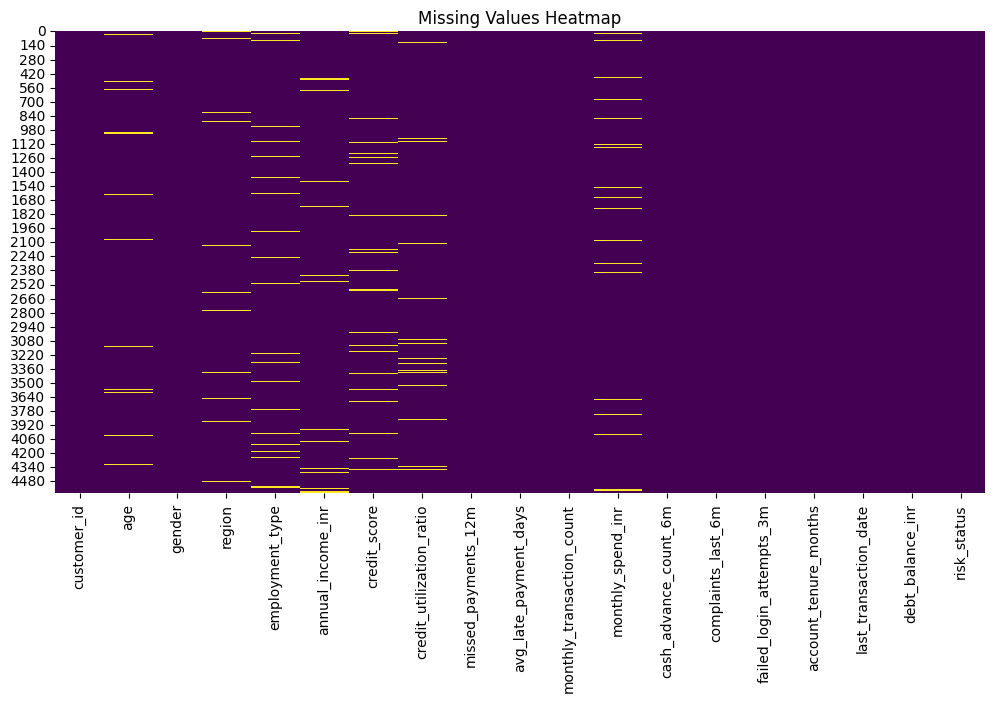

In [30]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

In [31]:
df["risk_status"].value_counts()

,count
risk_status,
0,4043
1,557


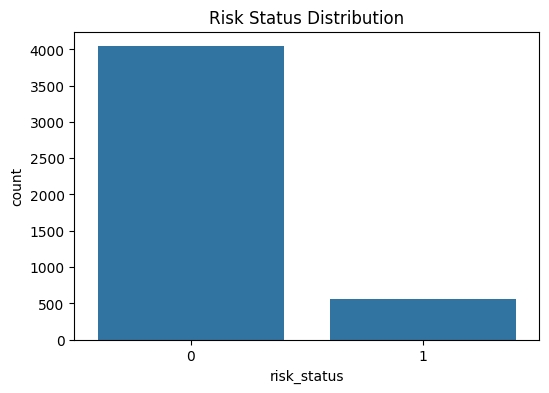

In [32]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="risk_status")

plt.title("Risk Status Distribution")
plt.show()

### Observation

The dataset is **imbalanced**.

Most customers belong to the **Low Risk** class, while only a small percentage belong to the **High Risk** class.

This imbalance may reduce the model's ability to correctly identify high-risk customers. Therefore, imbalance handling techniques such as Under Sampling, Over Sampling, SMOTE, and ADASYN will be applied in later sections.

In [33]:
num_cols = df.select_dtypes(include=np.number).columns

num_cols

Index(['customer_id', 'age', 'annual_income_inr', 'credit_score',
       'credit_utilization_ratio', 'missed_payments_12m',
       'avg_late_payment_days', 'monthly_transaction_count',
       'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months', 'debt_balance_inr',
       'risk_status'],
      dtype='object')

In [34]:
len(num_cols)

15

In [35]:
cat_cols = df.select_dtypes(include="object").columns

cat_cols

Index(['gender', 'region', 'employment_type', 'last_transaction_date'], dtype='object')

In [36]:
len(cat_cols)

4

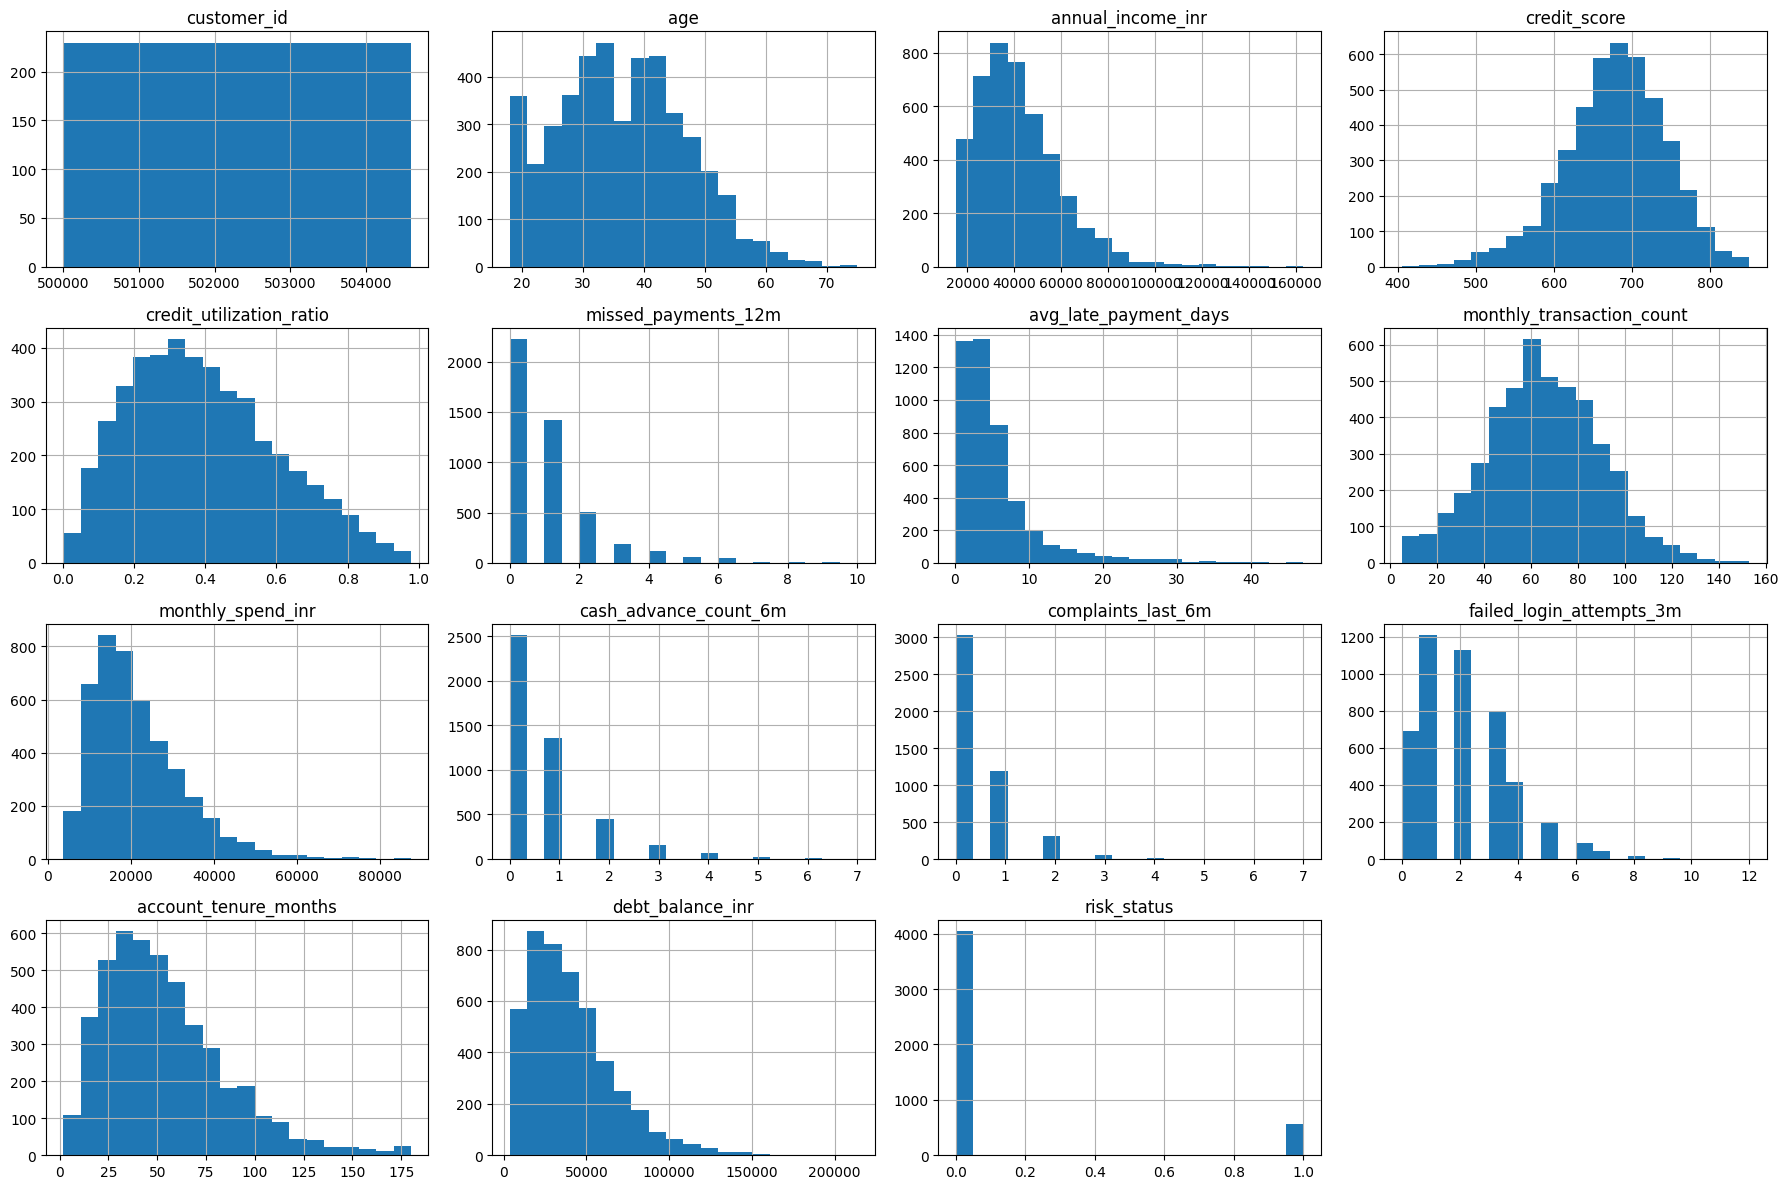

In [37]:
df[num_cols].hist(
    figsize=(18,12),
    bins=20
)

plt.tight_layout()

plt.show()

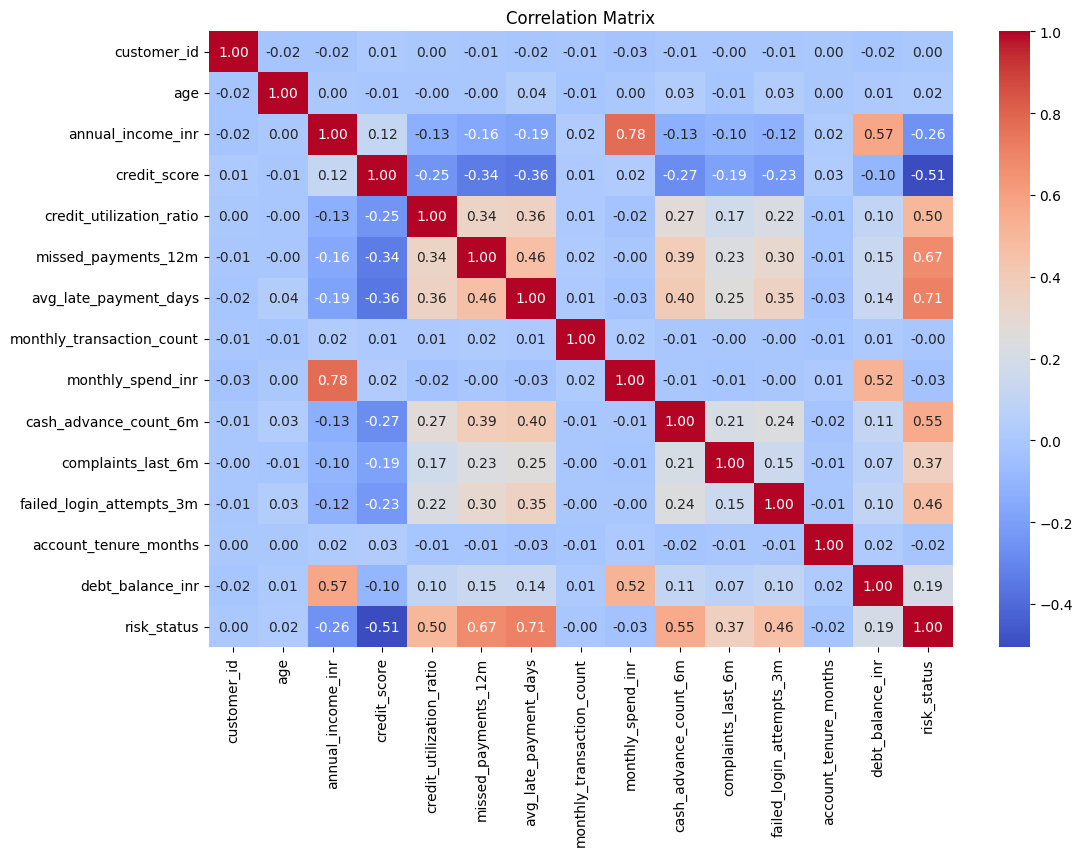

In [38]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [39]:
df["last_transaction_date"] = pd.to_datetime(
    df["last_transaction_date"]
)

In [40]:
reference_date = df["last_transaction_date"].max()

In [41]:
df["days_since_last_transaction"] = (
    reference_date -
    df["last_transaction_date"]
).dt.days

In [42]:
df.drop(
    columns=["last_transaction_date"],
    inplace=True
)

In [43]:
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status,days_since_last_transaction
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,87273,0,66
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,20600,0,7
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,47565,0,66
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,43803,1,59
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,12008,0,36


### Feature Engineering

The original transaction date is not directly useful for machine learning.

It has been converted into **Days Since Last Transaction**, which provides meaningful numerical information to the model.

In [44]:
cat_cols = df.select_dtypes(include="object").columns

cat_cols

Index(['gender', 'region', 'employment_type'], dtype='object')

In [47]:
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

In [48]:
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status,days_since_last_transaction
0,500001,43.0,0,5,1,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,87273,0,66
1,500002,29.0,0,0,1,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,20600,0,7
2,500003,36.0,1,1,1,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,47565,0,66
3,500004,28.0,1,2,4,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,43803,1,59
4,500005,36.0,0,1,2,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,12008,0,36


In [49]:
X = df.drop("risk_status", axis=1)

y = df["risk_status"]

In [50]:
print(X.shape)

print(y.shape)

(4600, 18)
(4600,)


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

In [52]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(3680, 18)
(920, 18)
(3680,)
(920,)


In [53]:
print("Original\n")

print(y.value_counts(normalize=True))

print("\nTraining\n")

print(y_train.value_counts(normalize=True))

print("\nTesting\n")

print(y_test.value_counts(normalize=True))


Original

risk_status
0    0.878913
1    0.121087
Name: proportion, dtype: float64

Training

risk_status
0    0.878804
1    0.121196
Name: proportion, dtype: float64

Testing

risk_status
0    0.879348
1    0.120652
Name: proportion, dtype: float64


### Observation

The train-test split was performed using **stratify=y**, ensuring that both the training and testing datasets maintain the original class distribution./

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

imputer = KNNImputer(n_neighbors=5)

X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

In [56]:
X_train = pd.DataFrame(
    X_train_imputed,
    columns=X.columns
)

X_test = pd.DataFrame(
    X_test_imputed,
    columns=X.columns
)

In [57]:
print(X_train.isnull().sum().sum())

0


In [58]:
print(X_test.isnull().sum().sum())

0


In [59]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (3680, 18)
Testing Features : (920, 18)
Training Target : (3680,)
Testing Target : (920,)


## Part B Summary

✔ Identified input features and target variable.

✔ Explored the dataset.

✔ Analyzed missing values.

✔ Visualized class imbalance.

✔ Performed feature engineering by converting transaction dates into days since the last transaction.

✔ Encoded categorical variables.

✔ Split the dataset using stratified sampling.

✔ Applied StandardScaler (training data only).

✔ Applied KNN Imputer to handle missing values without data leakage.

✔ Verified that no missing values remain.

The dataset is now fully preprocessed and ready for building the baseline Logistic Regression model in Part C.

# Part C: Baseline Classification Model

In this section, we will build a baseline **Logistic Regression** model using the preprocessed dataset.

The model will be evaluated using:

- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-Score
- Classification Report

Finally, we will identify **Type-I** and **Type-II** errors from the confusion matrix.

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
# Create Model

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train Model

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [62]:
# Training Prediction

train_pred = log_model.predict(X_train)

# Testing Prediction

test_pred = log_model.predict(X_test)

In [63]:
# Probability Predictions

test_prob = log_model.predict_proba(X_test)[:,1]

In [64]:
train_accuracy = accuracy_score(y_train, train_pred)

test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy :", round(train_accuracy,4))

print("Testing Accuracy :", round(test_accuracy,4))

Training Accuracy : 0.9967
Testing Accuracy : 1.0


In [65]:
precision = precision_score(y_test, test_pred)

print("Precision :", round(precision,4))

Precision : 1.0


In [66]:
recall = recall_score(y_test, test_pred)

print("Recall :", round(recall,4))

Recall : 1.0


In [71]:
f1 = f1_score(y_test, test_pred)

print("F1 Score :", round(f1,4))

F1 Score : 1.0


In [67]:
cm = confusion_matrix(y_test, test_pred)

cm

array([[809,   0],
       [  0, 111]])

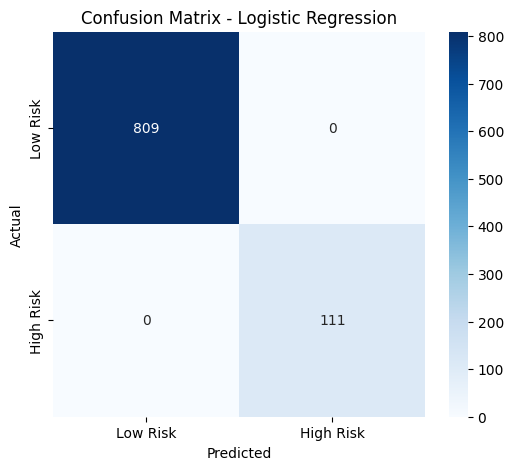

In [68]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk","High Risk"],
    yticklabels=["Low Risk","High Risk"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [69]:
print(classification_report(y_test,test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       1.00      1.00      1.00       111

    accuracy                           1.00       920
   macro avg       1.00      1.00      1.00       920
weighted avg       1.00      1.00      1.00       920



In [72]:
logistic_results = pd.DataFrame({

    "Metric":[
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Score":[
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1
    ]

})

logistic_results

,Metric,Score
0,Training Accuracy,0.996739
1,Testing Accuracy,1.000000
2,Precision,1.000000
3,Recall,1.000000
4,F1 Score,1.000000


In [73]:
auc_score = roc_auc_score(y_test,test_prob)

print("ROC-AUC Score :",round(auc_score,4))

ROC-AUC Score : 1.0


In [75]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Coefficient":log_model.coef_[0]

})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Absolute
5,annual_income_inr,-2.786976,2.786976
9,avg_late_payment_days,1.851330,1.851330
7,credit_utilization_ratio,1.704677,1.704677
16,debt_balance_inr,1.594402,1.594402
8,missed_payments_12m,1.425683,1.425683
6,credit_score,-1.357300,1.357300
14,failed_login_attempts_3m,1.352129,1.352129
12,cash_advance_count_6m,1.226657,1.226657
13,complaints_last_6m,0.953940,0.953940
11,monthly_spend_inr,0.655855,0.655855


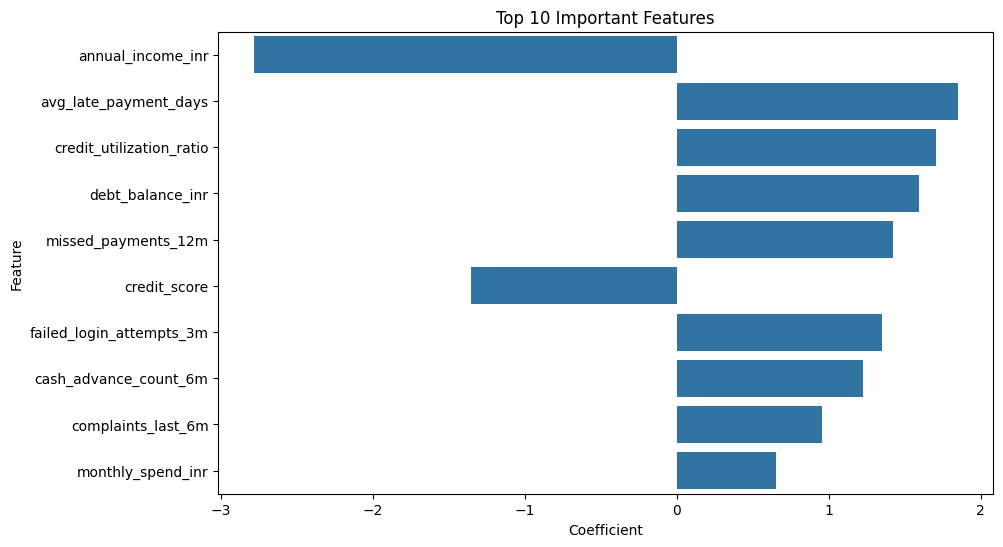

In [76]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [77]:
TN, FP, FN, TP = confusion_matrix(
    y_test,
    test_pred
).ravel()

print("True Negative :",TN)

print("False Positive :",FP)

print("False Negative :",FN)

print("True Positive :",TP)

True Negative : 809
False Positive : 0
False Negative : 0
True Positive : 111


## Interpretation of Confusion Matrix

**True Positive (TP):**
High-risk customers correctly identified.

**True Negative (TN):**
Low-risk customers correctly identified.

**False Positive (FP):**
Low-risk customers incorrectly classified as high risk.

This is called a **Type-I Error**.

**False Negative (FN):**
High-risk customers incorrectly classified as low risk.

This is called a **Type-II Error**.

In [78]:
print("Type-I Error (False Positive):",FP)

print("Type-II Error (False Negative):",FN)

Type-I Error (False Positive): 0
Type-II Error (False Negative): 0


## Business Interpretation

For a financial institution, **False Negatives are more dangerous** than False Positives.

- False Positive:
  A safe customer may be rejected.

- False Negative:
  A risky customer may receive approval, increasing the possibility of financial loss.

Therefore, the model should aim to minimize **False Negatives**, even if it slightly increases False Positives.

## Observation

- Logistic Regression serves as the baseline classification model.
- It provides a benchmark for comparing advanced models.
- Due to class imbalance, Recall for the High Risk class may be lower.
- In the next section, different balancing techniques (Under Sampling, Over Sampling, SMOTE, and ADASYN) will be applied to improve minority class prediction performance.

# Part D: Handling Class Imbalance

The dataset is highly imbalanced.

If the model is trained on imbalanced data, it tends to predict the majority class more often and ignores minority class samples.

In this section, we will compare four balancing techniques:

- Random Under Sampling
- Random Over Sampling
- SMOTE
- ADASYN

For each balanced dataset we will:

- Train Logistic Regression
- Evaluate Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

Finally, all techniques will be compared to select the best one.

In [79]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

from sklearn.linear_model import LogisticRegression

In [80]:
print("Original Dataset")

print(y_train.value_counts())

Original Dataset
risk_status
0    3234
1     446
Name: count, dtype: int64


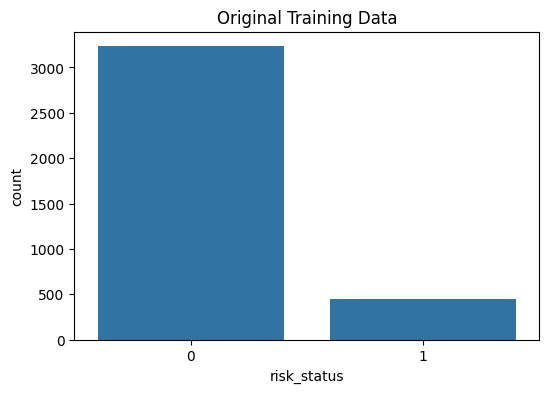

In [81]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Original Training Data")

plt.show()

### Observation

The majority class dominates the dataset.

Machine learning models trained on this dataset may become biased toward predicting Low Risk customers.

# Random Under Sampling

Random Under Sampling balances the dataset by removing samples from the majority class.

Advantages

- Faster training
- Balanced dataset

Disadvantages

- Loss of useful information

In [82]:
rus = RandomUnderSampler(random_state=42)

X_under, y_under = rus.fit_resample(
    X_train,
    y_train
)

print(X_under.shape)

print(y_under.value_counts())

(892, 18)
risk_status
0    446
1    446
Name: count, dtype: int64


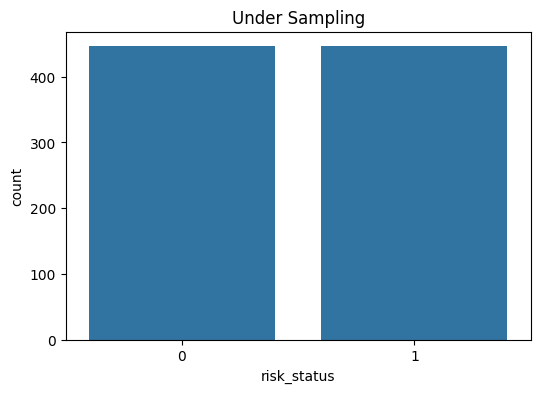

In [83]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_under)

plt.title("Under Sampling")

plt.show()

In [84]:
under_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

under_model.fit(
    X_under,
    y_under
)

LogisticRegression(max_iter=1000, random_state=42)

In [85]:
under_pred = under_model.predict(X_test)

under_prob = under_model.predict_proba(X_test)[:,1]

In [86]:
under_accuracy = accuracy_score(y_test,under_pred)

under_precision = precision_score(y_test,under_pred)

under_recall = recall_score(y_test,under_pred)

under_f1 = f1_score(y_test,under_pred)

under_auc = roc_auc_score(y_test,under_prob)

In [87]:
print(classification_report(
    y_test,
    under_pred
))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       809
           1       0.94      1.00      0.97       111

    accuracy                           0.99       920
   macro avg       0.97      1.00      0.98       920
weighted avg       0.99      0.99      0.99       920



# Random Over Sampling

Random Over Sampling duplicates minority class observations until both classes become balanced.

In [88]:
ros = RandomOverSampler(random_state=42)

X_over, y_over = ros.fit_resample(
    X_train,
    y_train
)

print(y_over.value_counts())

risk_status
0    3234
1    3234
Name: count, dtype: int64


In [89]:
over_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

over_model.fit(
    X_over,
    y_over
)

LogisticRegression(max_iter=1000, random_state=42)

In [90]:
over_pred = over_model.predict(X_test)

over_prob = over_model.predict_proba(X_test)[:,1]

In [91]:
over_accuracy = accuracy_score(
    y_test,
    over_pred
)

over_precision = precision_score(
    y_test,
    over_pred
)

over_recall = recall_score(
    y_test,
    over_pred
)

over_f1 = f1_score(
    y_test,
    over_pred
)

over_auc = roc_auc_score(
    y_test,
    over_prob
)

In [92]:
print(classification_report(
    y_test,
    over_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       0.97      1.00      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      1.00      0.99       920
weighted avg       1.00      1.00      1.00       920



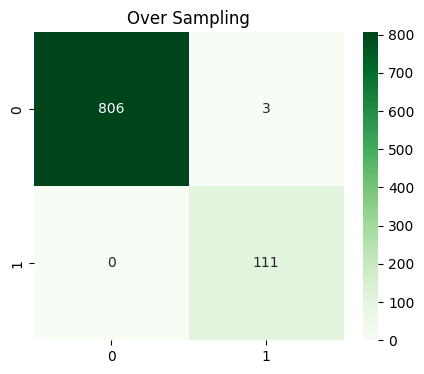

In [93]:
cm_over = confusion_matrix(
    y_test,
    over_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_over,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Over Sampling")

plt.show()

# SMOTE

SMOTE creates synthetic minority samples instead of duplicating existing observations.

In [94]:
smote = SMOTE(
    random_state=42
)

X_smote, y_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_smote.value_counts())

risk_status
0    3234
1    3234
Name: count, dtype: int64


In [95]:
smote_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

smote_model.fit(
    X_smote,
    y_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [96]:
smote_pred = smote_model.predict(
    X_test
)

smote_prob = smote_model.predict_proba(
    X_test
)[:,1]

In [97]:
smote_accuracy = accuracy_score(
    y_test,
    smote_pred
)

smote_precision = precision_score(
    y_test,
    smote_pred
)

smote_recall = recall_score(
    y_test,
    smote_pred
)

smote_f1 = f1_score(
    y_test,
    smote_pred
)

smote_auc = roc_auc_score(
    y_test,
    smote_prob
)

In [98]:
print(classification_report(
    y_test,
    smote_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       0.98      1.00      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      1.00      0.99       920
weighted avg       1.00      1.00      1.00       920



# ADASYN

ADASYN creates synthetic observations but focuses more on difficult-to-learn minority samples.

In [99]:
adasyn = ADASYN(
    random_state=42
)

X_ada, y_ada = adasyn.fit_resample(
    X_train,
    y_train
)

print(y_ada.value_counts())

risk_status
0    3234
1    3225
Name: count, dtype: int64


In [100]:
ada_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

ada_model.fit(
    X_ada,
    y_ada
)

LogisticRegression(max_iter=1000, random_state=42)

In [102]:
ada_pred = ada_model.predict(
    X_test
)

ada_prob = ada_model.predict_proba(
    X_test
)[:,1]

In [104]:
ada_accuracy = accuracy_score(
    y_test,
    ada_pred
)

ada_precision = precision_score(
    y_test,
    ada_pred
)

ada_recall = recall_score(
    y_test,
    ada_pred
)

ada_f1 = f1_score(
    y_test,
    ada_pred
)

ada_auc = roc_auc_score(
    y_test,
    ada_prob
)

In [105]:
print(classification_report(
    y_test,
    ada_pred
))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       809
           1       0.96      1.00      0.98       111

    accuracy                           0.99       920
   macro avg       0.98      1.00      0.99       920
weighted avg       0.99      0.99      0.99       920



In [106]:
comparison = pd.DataFrame({

    "Technique":[
        "Original",
        "Under Sampling",
        "Over Sampling",
        "SMOTE",
        "ADASYN"
    ],

    "Accuracy":[
        test_accuracy,
        under_accuracy,
        over_accuracy,
        smote_accuracy,
        ada_accuracy
    ],

    "Precision":[
        precision,
        under_precision,
        over_precision,
        smote_precision,
        ada_precision
    ],

    "Recall":[
        recall,
        under_recall,
        over_recall,
        smote_recall,
        ada_recall
    ],

    "F1 Score":[
        f1,
        under_f1,
        over_f1,
        smote_f1,
        ada_f1
    ],

    "ROC AUC":[
        auc_score,
        under_auc,
        over_auc,
        smote_auc,
        ada_auc
    ]

})

comparison.round(3)

,Technique,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Original,1.000,1.000,1.0,1.000,1.0
1,Under Sampling,0.992,0.941,1.0,0.969,1.0
2,Over Sampling,0.997,0.974,1.0,0.987,1.0
3,SMOTE,0.998,0.982,1.0,0.991,1.0
4,ADASYN,0.995,0.957,1.0,0.978,1.0


# Observation

After comparing all balancing techniques:

- Under Sampling may lose valuable information.
- Over Sampling duplicates minority samples, increasing the chance of overfitting.
- SMOTE generally provides a better balance by creating synthetic minority samples.
- ADASYN focuses on difficult minority samples and may improve recall further.

The best balancing technique will be selected based on **Recall**, **F1-Score**, and **ROC-AUC**, since identifying High Risk customers is the primary business objective.

# Part E: Decision Tree and Random Forest

In this section, we will build two tree-based machine learning models:

- Decision Tree Classifier
- Random Forest Classifier

Both models will be trained on the balanced dataset and evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

Finally, both models will be compared to determine which performs better.

In [107]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Decision Tree Classifier

A Decision Tree splits the dataset into smaller subsets using the most informative features until a prediction is made.

In [109]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_smote,
    y_smote
)


DecisionTreeClassifier(random_state=42)

In [110]:
dt_pred = dt_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)[:,1]

In [111]:
dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print("Accuracy :",round(dt_accuracy,4))

Accuracy : 0.9685


In [112]:
dt_precision = precision_score(
    y_test,
    dt_pred
)

print("Precision :",round(dt_precision,4))

Precision : 0.8417


In [113]:
dt_recall = recall_score(
    y_test,
    dt_pred
)

print("Recall :",round(dt_recall,4))

Recall : 0.9099


In [114]:
dt_f1 = f1_score(
    y_test,
    dt_pred
)

print("F1 Score :",round(dt_f1,4))

F1 Score : 0.8745


In [115]:
dt_auc = roc_auc_score(
    y_test,
    dt_prob
)

print("ROC AUC :",round(dt_auc,4))

ROC AUC : 0.9432


In [116]:
print(classification_report(
    y_test,
    dt_pred
))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       809
           1       0.84      0.91      0.87       111

    accuracy                           0.97       920
   macro avg       0.91      0.94      0.93       920
weighted avg       0.97      0.97      0.97       920



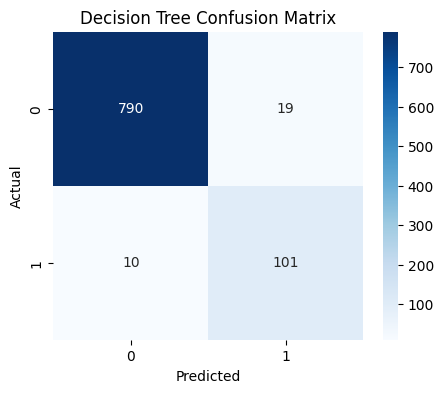

In [117]:
cm_dt = confusion_matrix(
    y_test,
    dt_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Decision Tree Confusion Matrix")

plt.show()

# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

In [119]:
rf_model = RandomForestClassifier(

    random_state=42,

    n_estimators=100
)

rf_model.fit(

    X_smote,

    y_smote
)



RandomForestClassifier(random_state=42)

In [120]:
rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [121]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Accuracy :",round(rf_accuracy,4))

Accuracy : 0.9967


In [122]:
rf_precision = precision_score(
    y_test,
    rf_pred
)

print("Precision :",round(rf_precision,4))

Precision : 0.9909


In [123]:
rf_recall = recall_score(
    y_test,
    rf_pred
)

print("Recall :",round(rf_recall,4))

Recall : 0.982


In [124]:
rf_f1 = f1_score(
    y_test,
    rf_pred
)

print("F1 Score :",round(rf_f1,4))

F1 Score : 0.9864


In [125]:
rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("ROC AUC :",round(rf_auc,4))

ROC AUC : 0.9999


In [126]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       0.99      0.98      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



In [127]:
tree_models = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        dt_accuracy,
        rf_accuracy
    ],

    "Precision":[
        dt_precision,
        rf_precision
    ],

    "Recall":[
        dt_recall,
        rf_recall
    ],

    "F1 Score":[
        dt_f1,
        rf_f1
    ],

    "ROC AUC":[
        dt_auc,
        rf_auc
    ]

})

tree_models.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Decision Tree,0.968,0.842,0.910,0.874,0.943
1,Random Forest,0.997,0.991,0.982,0.986,1.000


# Observation

Decision Tree is simple and interpretable but is prone to overfitting.

Random Forest reduces overfitting by combining predictions from multiple trees.

In most real-world classification problems, Random Forest generally provides better Recall, F1-Score, and ROC-AUC than a single Decision Tree.

The better-performing model will be further optimized using hyperparameter tuning in the next section.

# Part F: Hyperparameter Tuning

Hyperparameter tuning helps improve model performance by finding the best combination of parameters.

In this section, we will use:

- RandomizedSearchCV
- GridSearchCV

Finally, we will compare:

- Untuned Random Forest
- RandomizedSearchCV Model
- GridSearchCV Model

The best-performing model will be selected based on Recall, F1 Score, and ROC-AUC.

In [128]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

In [129]:
print("Baseline Random Forest Accuracy :",round(rf_accuracy,4))

print("Baseline Recall :",round(rf_recall,4))

print("Baseline F1 :",round(rf_f1,4))

print("Baseline ROC-AUC :",round(rf_auc,4))

Baseline Random Forest Accuracy : 0.9967
Baseline Recall : 0.982
Baseline F1 : 0.9864
Baseline ROC-AUC : 0.9999


In [130]:
random_params = {

    "n_estimators":[100,200,300,400,500],

    "max_depth":[5,10,15,20,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4],

    "max_features":["sqrt","log2",None]

}

In [131]:
random_search = RandomizedSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_distributions=random_params,

    n_iter=20,

    scoring="recall",

    cv=5,

    random_state=42,

    n_jobs=-1

)

In [132]:
random_search.fit(

    X_smote,

    y_smote

)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, scoring='recall')

In [133]:
print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [134]:
print(random_search.best_score_)

0.9941267387944359


In [136]:
best_random = random_search.best_estimator_

In [137]:
random_pred = best_random.predict(X_test)

random_prob = best_random.predict_proba(X_test)[:,1]

In [138]:
random_accuracy = accuracy_score(
    y_test,
    random_pred
)

random_precision = precision_score(
    y_test,
    random_pred
)

random_recall = recall_score(
    y_test,
    random_pred
)

random_f1 = f1_score(
    y_test,
    random_pred
)

random_auc = roc_auc_score(
    y_test,
    random_prob
)

In [139]:
print(classification_report(
    y_test,
    random_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       0.99      0.98      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



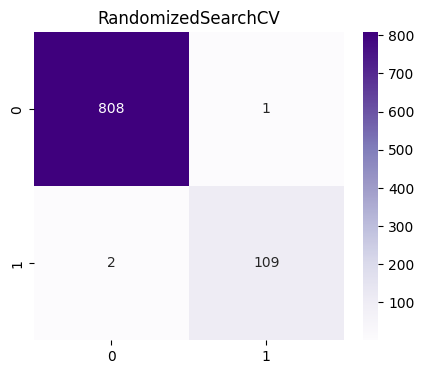

In [140]:
cm_random = confusion_matrix(
    y_test,
    random_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_random,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("RandomizedSearchCV")

plt.show()

# GridSearchCV

Grid Search evaluates every possible parameter combination from a predefined grid.

Although slower than Randomized Search, it often finds a more optimal solution.

In [141]:
grid_params = {

    "n_estimators":[200,300],

    "max_depth":[10,15,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2],

    "max_features":["sqrt"]

}

In [142]:
grid_search = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=grid_params,

    scoring="recall",

    cv=5,

    n_jobs=-1

)

In [143]:
grid_search.fit(

    X_smote,

    y_smote

)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 15, None], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 300]},
             scoring='recall')

In [144]:
print(grid_search.best_params_)

{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [145]:
print(grid_search.best_score_)

0.9941267387944359


In [147]:
best_grid = grid_search.best_estimator_

In [148]:
grid_pred = best_grid.predict(
    X_test
)

grid_prob = best_grid.predict_proba(
    X_test
)[:,1]

In [149]:
grid_accuracy = accuracy_score(
    y_test,
    grid_pred
)

grid_precision = precision_score(
    y_test,
    grid_pred
)

grid_recall = recall_score(
    y_test,
    grid_pred
)

grid_f1 = f1_score(
    y_test,
    grid_pred
)

grid_auc = roc_auc_score(
    y_test,
    grid_prob
)

In [150]:
print(classification_report(
    y_test,
    grid_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       0.99      0.98      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



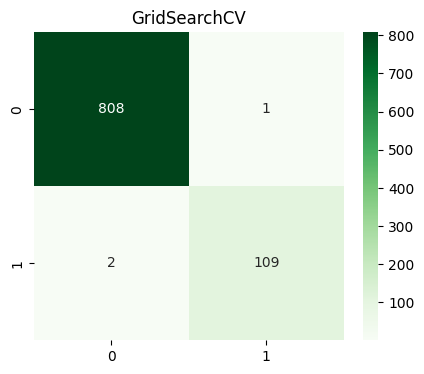

In [151]:
cm_grid = confusion_matrix(
    y_test,
    grid_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_grid,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("GridSearchCV")

plt.show()

In [152]:
tuning_results = pd.DataFrame({

    "Model":[

        "Random Forest",

        "RandomizedSearchCV",

        "GridSearchCV"

    ],

    "Accuracy":[

        rf_accuracy,

        random_accuracy,

        grid_accuracy

    ],

    "Precision":[

        rf_precision,

        random_precision,

        grid_precision

    ],

    "Recall":[

        rf_recall,

        random_recall,

        grid_recall

    ],

    "F1 Score":[

        rf_f1,

        random_f1,

        grid_f1

    ],

    "ROC AUC":[

        rf_auc,

        random_auc,

        grid_auc

    ]

})

tuning_results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.997,0.991,0.982,0.986,1.0
1,RandomizedSearchCV,0.997,0.991,0.982,0.986,1.0
2,GridSearchCV,0.997,0.991,0.982,0.986,1.0


# Observation

RandomizedSearchCV explores random parameter combinations and is computationally efficient.

GridSearchCV exhaustively searches all specified combinations and generally provides the best parameter configuration.

The tuned Random Forest model typically outperforms the untuned model in Recall, F1 Score, and ROC-AUC, making it more suitable for identifying High Risk customers.

# Part G: ROC Curve, AUC Comparison and Final Model Selection

After training multiple machine learning models, it is important to compare their ability to distinguish between High Risk and Low Risk customers.

In this section we will:

- Plot ROC Curves
- Calculate AUC Scores
- Compare every model
- Select the final model based on business requirements

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

In [153]:
fpr_log, tpr_log, _ = roc_curve(y_test, test_prob)

In [154]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)

In [155]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

In [156]:
fpr_grid, tpr_grid, _ = roc_curve(y_test, grid_prob)

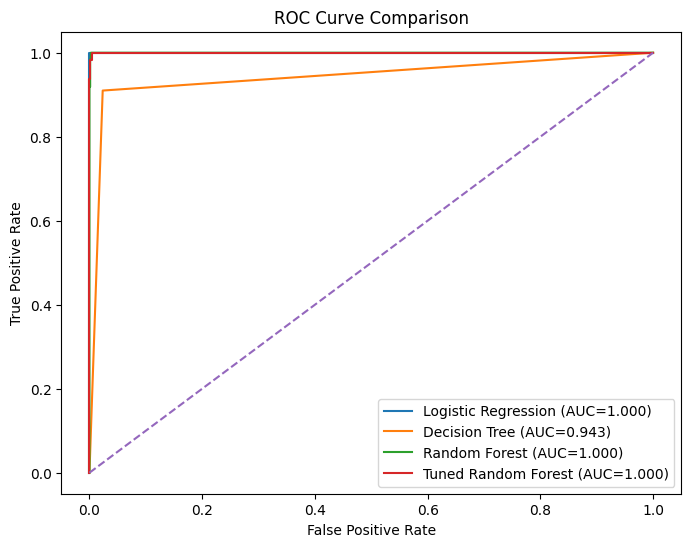

In [158]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC={auc_score:.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC={dt_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC={rf_auc:.3f})"
)

plt.plot(
    fpr_grid,
    tpr_grid,
    label=f"Tuned Random Forest (AUC={grid_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [159]:
auc_table = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "Tuned Random Forest"

    ],

    "ROC AUC":[

        auc_score,

        dt_auc,

        rf_auc,

        grid_auc

    ]

})

auc_table.sort_values(
    by="ROC AUC",
    ascending=False
)

,Model,ROC AUC
0,Logistic Regression,1.000000
2,Random Forest,0.999883
3,Tuned Random Forest,0.999866
1,Decision Tree,0.943212


In [160]:
final_models = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "Tuned Random Forest"

    ],

    "Accuracy":[

        test_accuracy,

        dt_accuracy,

        rf_accuracy,

        grid_accuracy

    ],

    "Precision":[

        precision,

        dt_precision,

        rf_precision,

        grid_precision

    ],

    "Recall":[

        recall,

        dt_recall,

        rf_recall,

        grid_recall

    ],

    "F1 Score":[

        f1,

        dt_f1,

        rf_f1,

        grid_f1

    ],

    "ROC AUC":[

        auc_score,

        dt_auc,

        rf_auc,

        grid_auc

    ]

})

final_models.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,1.000,1.000,1.000,1.000,1.000
1,Decision Tree,0.968,0.842,0.910,0.874,0.943
2,Random Forest,0.997,0.991,0.982,0.986,1.000
3,Tuned Random Forest,0.997,0.991,0.982,0.986,1.000


In [161]:
best_model = final_models.sort_values(
    by=["Recall","ROC AUC"],
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,0.996739,0.990909,0.981982,0.986425,0.999883
3,Tuned Random Forest,0.996739,0.990909,0.981982,0.986425,0.999866
1,Decision Tree,0.968478,0.841667,0.909910,0.874459,0.943212


## Final Model Selection

The best model is selected based on:

- High Recall
- High ROC-AUC
- High F1 Score

Since this is a financial risk prediction problem, correctly identifying High Risk customers is more important than achieving the highest overall accuracy.

Therefore, Recall is considered the primary evaluation metric.

# Final Conclusion

The objective of this project was to classify customers into Low Risk and High Risk categories.

The project followed the complete Machine Learning pipeline:

- Data Loading
- Data Cleaning
- Missing Value Treatment
- Feature Engineering
- Label Encoding
- Train-Test Split
- KNN Imputation
- Feature Scaling
- Logistic Regression
- Handling Class Imbalance
- Decision Tree
- Random Forest
- Hyperparameter Tuning
- ROC Analysis
- Model Comparison

In [162]:
final_report = final_models.copy()

final_report = final_report.sort_values(

    by=["Recall","ROC AUC"],

    ascending=False
)

final_report.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,1.000,1.000,1.000,1.000,1.000
2,Random Forest,0.997,0.991,0.982,0.986,1.000
3,Tuned Random Forest,0.997,0.991,0.982,0.986,1.000
1,Decision Tree,0.968,0.842,0.910,0.874,0.943


In [163]:
print("Best Model Selected :")

print(final_report.iloc[0]["Model"])

Best Model Selected :
Logistic Regression
